In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
cr=pd.read_csv('cp.csv')
cr.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


### Details
1) N:-Nitrogen ratio in soil
2) P:-ratio of phosphorous in soil
3) K:-ratio of potassium in soil
4) Temperature:-value in celsius
5) Humidity:-relative humidity in %
6) Ph:-Ph value in the soil
7) Rainfall:-rainfall water in mm
8) Label:-Is in string form of crop name

In [5]:
cr['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [6]:
cr.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [7]:
X=cr.drop(['label'],axis=1)
y=cr['label']
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


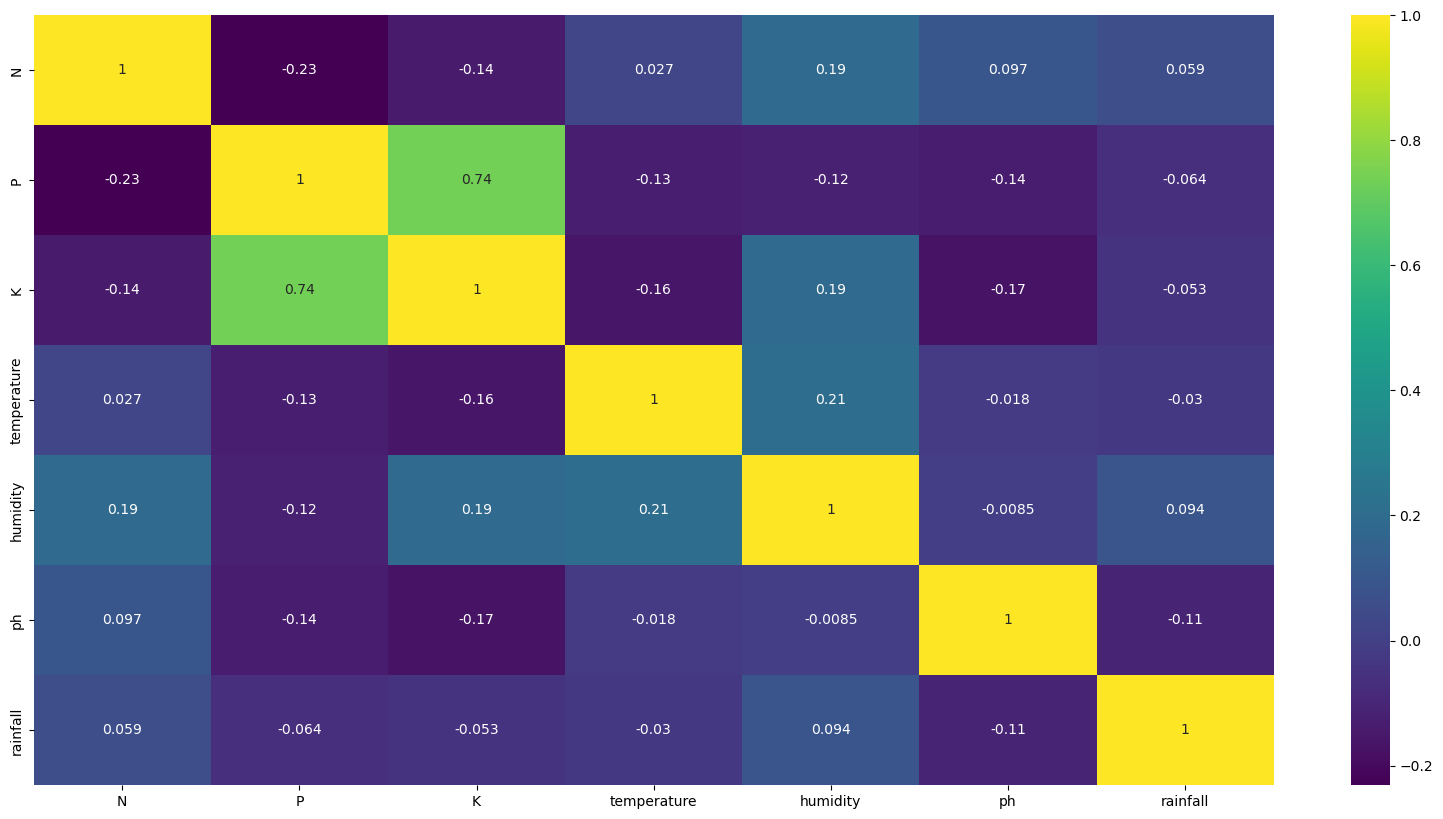

In [8]:
plt.figure(figsize=(20,10))
sns.heatmap(X.corr(),annot=True,cmap='viridis')
plt.show()

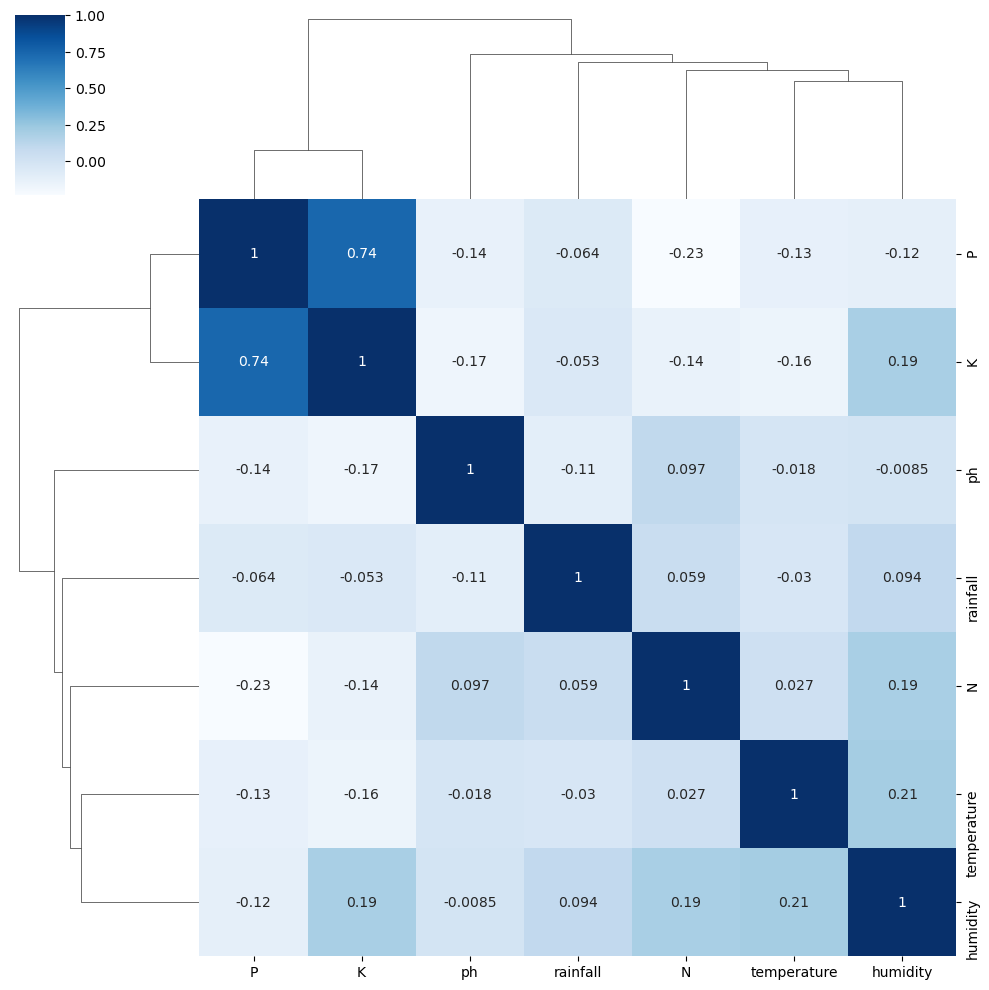

In [9]:
import scipy
# X = pd.DataFrame(np.random.rand(10, 5))
sns.clustermap(X.corr(),annot=True,cmap='Blues')
plt.show()

In [10]:
#creating of pivot table
pd.pivot_table(cr,index='label',
              values=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])

,K,N,P,humidity,ph,rainfall,temperature
label,,,,,,,
apple,199.89,20.80,134.22,92.333383,5.929663,112.654779,22.630942
banana,50.05,100.23,82.01,80.358123,5.983893,104.626980,27.376798
blackgram,19.24,40.02,67.47,65.118426,7.133952,67.884151,29.973340
chickpea,79.92,40.09,67.79,16.860439,7.336957,80.058977,18.872847
coconut,30.59,21.98,16.93,94.844272,5.976562,175.686646,27.409892
coffee,29.94,101.20,28.74,58.869846,6.790308,158.066295,25.540477
cotton,19.56,117.77,46.24,79.843474,6.912675,80.398043,23.988958
grapes,200.11,23.18,132.53,81.875228,6.025937,69.611829,23.849575
jute,39.99,78.40,46.86,79.639864,6.732778,174.792798,24.958376


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
X_train.shape,Y_train.shape,X_test.shape,Y_test.shape

((1760, 7), (1760,), (440, 7), (440,))

In [14]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression

In [15]:
log_reg=LogisticRegression()
log_reg.fit(X_train,Y_train)

LogisticRegression()

In [16]:
y_pred=log_reg.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

In [18]:
print("accuracy_score",accuracy_score(Y_test,y_pred)*100)

accuracy_score 94.54545454545455


In [19]:
import scikitplot as skplt

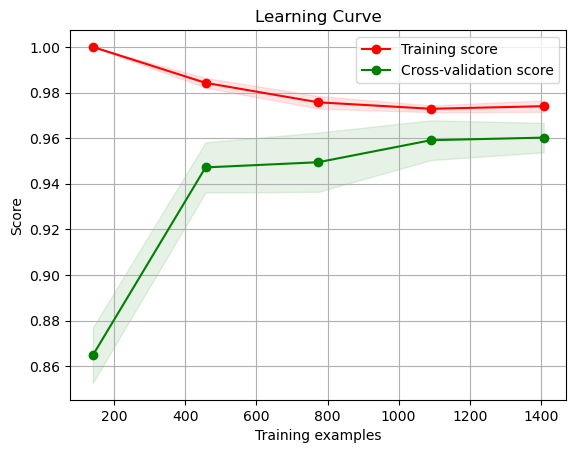

In [20]:
skplt.estimators.plot_learning_curve(log_reg,X_train,Y_train)
plt.show()

In [21]:
from sklearn.metrics import roc_auc_score
y_pred1_proba=log_reg.predict_proba(X_test)

In [22]:
class_1_prob=list()
for i in y_pred1_proba:
    class_1_prob.append(i)
print(roc_auc_score(Y_test,class_1_prob,multi_class='ovo')*100)

99.86984868689723


In [23]:
from sklearn.svm import SVC

In [24]:
svc_clf=SVC()
svc_clf.fit(X_train,Y_train)

SVC()

In [25]:
y_pred=svc_clf.predict(X_test)

In [26]:
print("accuracy_score",accuracy_score(Y_test,y_pred)*100)

accuracy_score 96.13636363636363


In [27]:
import pickle

In [28]:
with open('crop_model','wb')as f:
    pickle.dump(svc_clf,f)

In [1]:
N=int(input("Enter nitrogen"))
p=int(input("Enter phosphorus"))
k=int(input("Enter potassium"))
temp=float(input("Enter temperature: "))
humidity=float(input("Enter humidity :"))
ph=float(input("Enter ph "))
rainfall=float(input("Enter rainfall "))
userInput=[N,p,k,temp,humidity,ph,rainfall]

In [3]:
import pickle
with open('crop_model','rb')as f:
    mp=pickle.load(f)

In [4]:
mp.predict([userInput])

c:\Users\kanis\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['mothbeans'], dtype=object)